In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('dim_date.csv')

In [3]:
df2 = pd.read_csv('dim_hotels.csv')

In [4]:
df3 = pd.read_csv('dim_rooms.csv')

In [5]:
df4 = pd.read_csv('fact_aggregated_bookings.csv')
df5 = pd.read_csv('fact_bookings.csv')

In [6]:
df5

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,2022-07-29,2022-07-31,2022-08-03,1,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,2022-07-30,2022-07-31,2022-08-01,4,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,2022-07-30,2022-07-31,2022-08-02,1,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,2022-07-29,2022-07-31,2022-08-01,2,RT4,logtrip,2.0,Checked Out,32300,32300


In [7]:
df5['booking_platform'][df5['booking_status']=='Checked Out'].value_counts()[:2]

booking_platform
others          38586
makeyourtrip    18825
Name: count, dtype: int64

In [8]:
# lets take the first 2 booking platform (others A , makeyourtrip B)

In [9]:
a = df5[df5['booking_platform']=='others']['revenue_realized']
b = df5[df5['booking_platform']=='makeyourtrip']['revenue_realized']

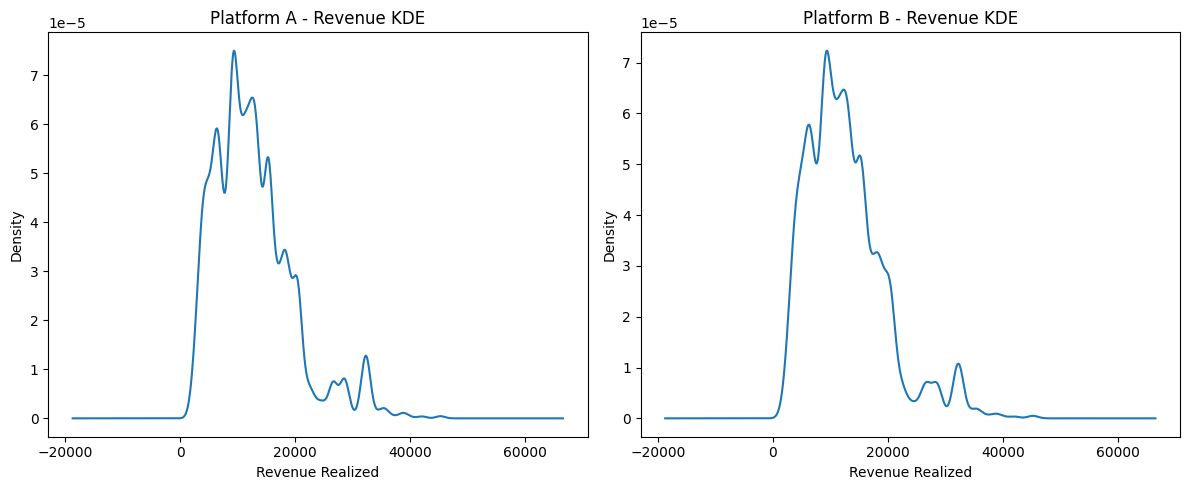

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Plot a on first subplot
a.plot(kind='kde', ax=axes[0], title='Platform A - Revenue KDE')
axes[0].set_xlabel("Revenue Realized")

# Plot b on second subplot
b.plot(kind='kde', ax=axes[1], title='Platform B - Revenue KDE')
axes[1].set_xlabel("Revenue Realized")

plt.tight_layout()
plt.show()

In [11]:
print(f"The standard deviation of A is {a.std()} and the standard deviation of B is {b.std()}")

The standard deviation of A is 6951.853115622277 and the standard deviation of B is 6893.938549702959


In [12]:
# we see the data is not normal but since our sample is large we can use t test
# also the std dev of both data is not equal and hence we have to use a welch t test

In [13]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(a, b, equal_var=False,alternative='greater')  # Welch’s t-test
print(f"Welch’s t-test: t = {t_stat:.3f}, p-value = {p_val:.4f}")

Welch’s t-test: t = 0.562, p-value = 0.2870


In [14]:
from scipy.stats import mannwhitneyu
# Run Mann-Whitney U Test
u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
print(f"Mann-Whitney U: U = {u_stat:.2f}, p = {p_val:.4f}")

Mann-Whitney U: U = 741308042.50, p = 0.8195


In [15]:
import numpy as np

mean_diff = a.mean() - b.mean()
pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"Cohen’s d = {cohens_d:.3f}")

Cohen’s d = 0.004


In [16]:
# “A Mann-Whitney U test found no significant difference in median revenue per booking between makeyourtrip and others (U = ..., p = 0.81). Additionally, Cohen’s d = 0.002 indicates a negligible effect size. These results suggest that both platforms are equivalent in terms of per-booking revenue generation.”

In [17]:
from scipy.stats import f_oneway

# Filter to 'Checked Out' bookings
completed = df5[df5['booking_status'] == 'Checked Out']

# Group data by platform
platform_groups = [
    group['revenue_realized'].values
    for name, group in completed.groupby('booking_platform')
]

# Perform ANOVA
f_stat, p_val = f_oneway(*platform_groups)
print(f"ANOVA F = {f_stat:.3f}, p = {p_val:.4f}")


ANOVA F = 1.028, p = 0.4048


In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    completed['revenue_realized'],
    completed['booking_platform'],
    alpha=0.05
)
print(tukey)


         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1         group2    meandiff p-adj    lower    upper   reject
----------------------------------------------------------------------
direct offline direct online  -87.209 0.9888 -426.5715 252.1535  False
direct offline       journey -109.441  0.978  -483.688 264.8059  False
direct offline       logtrip -63.0914 0.9979 -396.8639 270.6811  False
direct offline  makeyourtrip -74.8125 0.9919 -384.3866 234.7617  False
direct offline        others   0.4638    1.0 -292.7264 293.6541  False
direct offline      tripster  92.8008 0.9888 -268.4916 454.0932  False
 direct online       journey -22.2321    1.0  -341.798 297.3339  False
 direct online       logtrip  24.1175    1.0  -246.928 295.1631  False
 direct online  makeyourtrip  12.3965    1.0 -228.2231 253.0161  False
 direct online        others  87.6728  0.902 -131.4667 306.8124  False
 direct online      tripster 180.0098 0.5861 -124.2826 484.3021  False
      

In [19]:
# hence we see no pairs differ in average revenue per booking


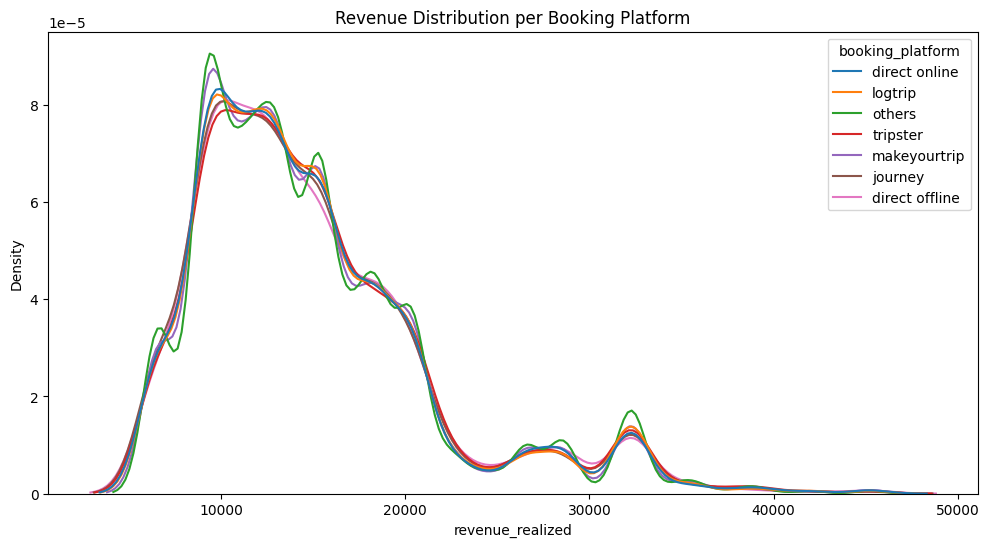

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.kdeplot(data=completed, x='revenue_realized', hue='booking_platform', common_norm=False)
plt.title("Revenue Distribution per Booking Platform")
plt.show()

# we see havey tails in booking_platform but since for every group our data is quite large so normality assumption holds by clt
# we should check if the variance among all groups are equal by leveene test

In [21]:
### from scipy.stats import levene
from scipy.stats import levene

platform_groups = [
    group['revenue_realized'].values
    for name, group in completed.groupby('booking_platform')
]

levene_stat, levene_p = levene(*platform_groups)
print(f"Levene’s Test p-value = {levene_p:.4f}")


Levene’s Test p-value = 0.5678


In [22]:
platform_groups

[array([10010, 12600, 12155, ..., 18000, 19800, 11050], dtype=int64),
 array([10010, 10920, 12600, ..., 22440, 20400, 32300], dtype=int64),
 array([10920, 11050, 11050, ..., 28500, 13500, 28500], dtype=int64),
 array([ 9100,  9100, 12600, ..., 20400, 38760, 32300], dtype=int64),
 array([ 9100,  9100, 12600, ..., 15300, 38760, 32300], dtype=int64),
 array([ 9100,  9100,  9100, ..., 20400, 32300, 32300], dtype=int64),
 array([ 9100, 12600, 26600, ..., 13500, 15300, 20400], dtype=int64)]

In [23]:
from scipy.stats import kruskal

kw_stat, kw_p = kruskal(*platform_groups)
print(f"p-value is {kw_p}")

p-value is 0.48686944787067077


In [24]:
# levenne test in null hypothesis that all groups have equal variance , alternative is atleast one group has different variance
# we can use anova test as levene's test suggest we dont have significant evidence to reject the null hypothesis

In [25]:
# so by both anova test and kruskal walis test , the mean revenue generated by different platforms dont differ significantly and neither their pairs differ

In [26]:
df_f = pd.merge(df5,df3,how='inner',left_on='room_category',right_on='room_id')

In [27]:
df_f.drop(columns='room_id',inplace=True)

In [28]:
df_f

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,room_class
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010,Standard
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640,Standard
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100,Standard
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640,Standard
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,2022-07-29,2022-07-31,2022-08-03,1,RT4,makeyourtrip,2.0,Checked Out,32300,32300,Presidential
134586,Jul312217564RT47,17564,2022-07-30,2022-07-31,2022-08-01,4,RT4,logtrip,2.0,Checked Out,38760,38760,Presidential
134587,Jul312217564RT48,17564,2022-07-30,2022-07-31,2022-08-02,1,RT4,tripster,NaN,Cancelled,32300,12920,Presidential
134588,Jul312217564RT49,17564,2022-07-29,2022-07-31,2022-08-01,2,RT4,logtrip,2.0,Checked Out,32300,32300,Presidential


In [29]:
df_f.isna().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77907
booking_status           0
revenue_generated        0
revenue_realized         0
room_class               0
dtype: int64

In [30]:
groups = df_f.groupby('room_class')['revenue_generated'].apply(list)

In [31]:
groups.values

array([list([12600, 12600, 12600, 13860, 12600, 12600, 13860, 12600, 12600, 12600, 12600, 12600, 12600, 15120, 12600, 12600, 15120, 12600, 13860, 12600, 12600, 16830, 15300, 16830, 15300, 15300, 15300, 18360, 15300, 16830, 16830, 18360, 15300, 15300, 15300, 15300, 15300, 18360, 15300, 16830, 15300, 15300, 15300, 15300, 15300, 15300, 18360, 15300, 18360, 15300, 15300, 15300, 15300, 15300, 15300, 15300, 12600, 12600, 12600, 12600, 12600, 15120, 12600, 13860, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 15120, 15120, 12600, 12600, 13860, 12600, 12600, 12600, 13860, 13860, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 15120, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 12600, 13860, 13860, 12600, 12600, 12600, 15120, 12600, 12600, 13860, 13860, 12600, 12600, 12600, 15120, 12600, 12600, 12600, 12600, 13860, 12600, 12600, 12600, 12600, 12600, 15120, 12600, 

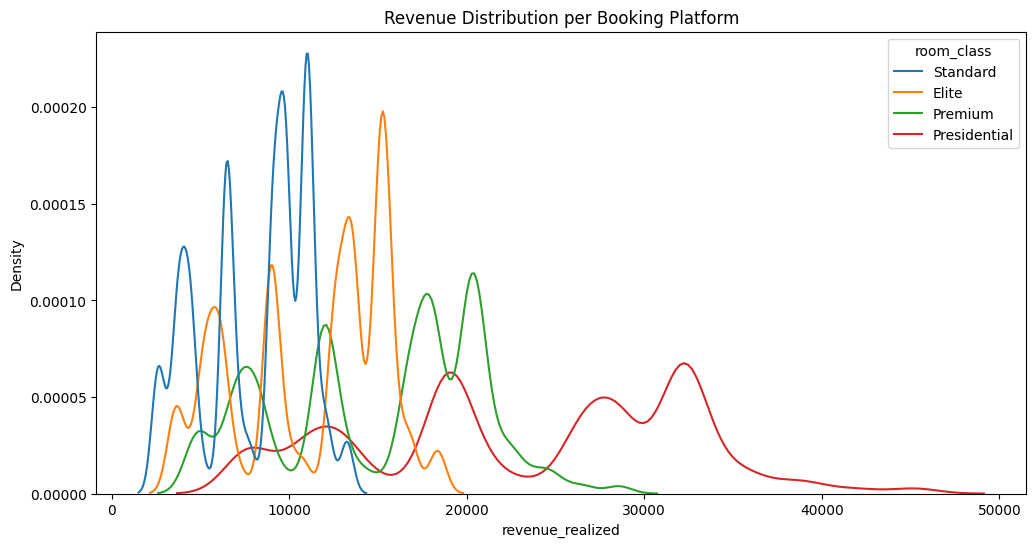

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_f, x='revenue_realized', hue='room_class', common_norm=False)
plt.title("Revenue Distribution per Booking Platform")
plt.show()

In [33]:
levene_stat, levene_p = levene(*groups)
print(f"Levene’s Test p-value = {levene_p:.4f}")

Levene’s Test p-value = 0.0000


In [34]:
# we cant use 1 way anova

In [35]:
kw_stat, kw_p = kruskal(*groups)
print(f"p-value is {kw_p}")

p-value is 0.0


In [36]:
import pingouin as pg

# Welch’s ANOVA
welch_result = pg.welch_anova(dv='revenue_realized', between='room_class', data=df_f)

print(welch_result)

       Source  ddof1        ddof2             F  p-unc      np2
0  room_class      3  50109.59136  26928.201968    0.0  0.45791


In [37]:
# P-value = 0.0
# Statistically significant difference in mean revenue across at least one pair of room_class groups
# You reject the null hypothesis (which states that all group means are equal)

# Effect size (np2) = 0.458
# This is a large effect size (rules of thumb: 0.01 = small, 0.06 = medium, 0.14+ = large)
# Room class explains ~46% of the variance in revenue

In [38]:
# Checking revenue_leakage across different cities and hotels and different seasons to validate seasonal leakage in hospitality 

In [39]:
df2

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi
5,16563,Atliq Palace,Business,Delhi
6,17558,Atliq Grands,Luxury,Mumbai
7,17559,Atliq Exotica,Luxury,Mumbai
8,17560,Atliq City,Business,Mumbai
9,17561,Atliq Blu,Luxury,Mumbai


In [40]:
df_f2 = pd.merge(df_f,df2,on='property_id')

In [41]:
df_f2['revenue_leakage']=df_f2['revenue_generated']-df_f2['revenue_realized']

In [42]:
gp = df_f2.groupby('city')['revenue_leakage'].apply(list)

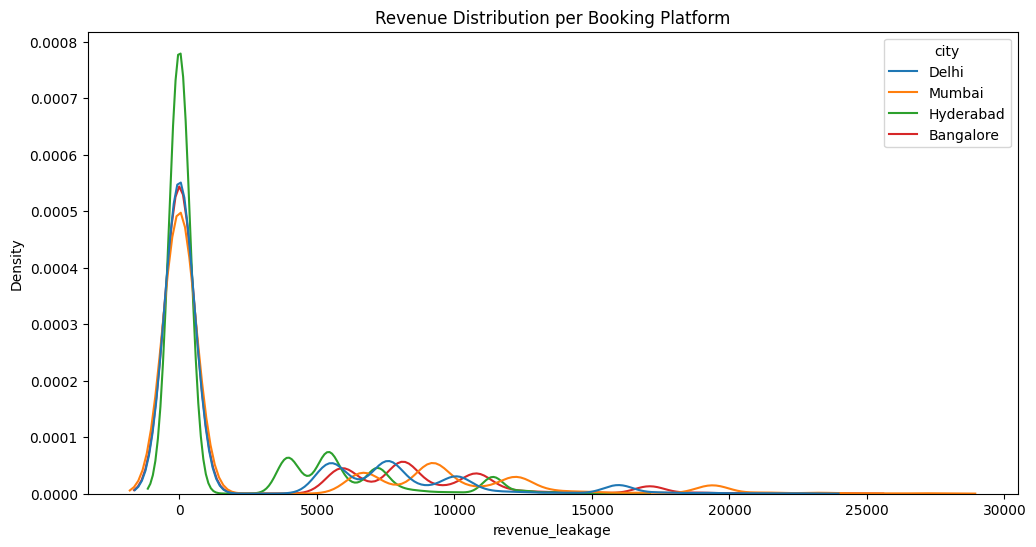

In [43]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_f2, x='revenue_leakage', hue='city', common_norm=False)
plt.title("Revenue Distribution per Booking Platform")
plt.show()

In [44]:
levene_stat, levene_p = levene(*gp)
print(f"Levene’s Test p-value = {levene_p:.4f}")

Levene’s Test p-value = 0.0000


In [45]:
kw_stat, kw_p = kruskal(*gp)
print(f"p-value is {kw_p}")
# so we conclude there is significant difference between all the groups 

p-value is 2.8119435926893664e-52


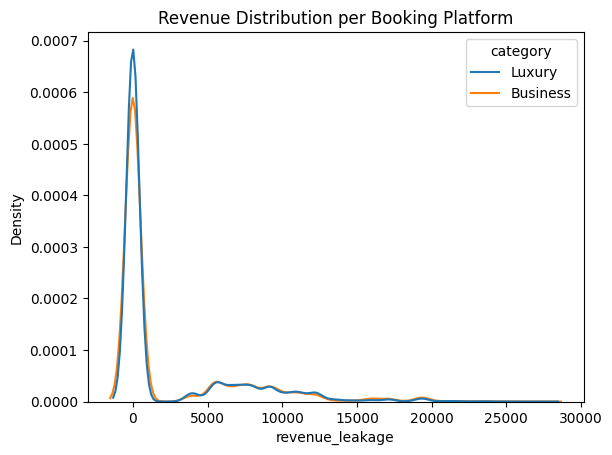

In [46]:
sns.kdeplot(data=df_f2, x='revenue_leakage', hue='category', common_norm=False)
plt.title("Revenue Distribution per Booking Platform")
plt.show()

In [47]:
gp2 = df_f2.groupby('category')['revenue_leakage'].apply(list)

In [48]:
a = df_f2[df_f2['category']=='Luxury']['revenue_leakage']
b = df_f2[df_f2['category']=='Business']['revenue_leakage']

In [49]:
u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
print(f"Mann-Whitney U: U = {u_stat:.2f}, p = {p_val:.4f}")

Mann-Whitney U: U = 2120503090.50, p = 0.0590


In [50]:
# therefore we conclude there is no (fail to reject h0) difference between the two categories

In [76]:
# Merge date to bookings
import scipy.stats as stats
df5['booking_date'] = pd.to_datetime(df5['booking_date'])
df1['date'] = pd.to_datetime(df1['date'])

bookings_with_day = df5.merge(df1, left_on='booking_date', right_on='date')

weekend = bookings_with_day[bookings_with_day['day_type'] == 'weekend']['revenue_realized']
weekday = bookings_with_day[bookings_with_day['day_type'] == 'weekeday']['revenue_realized']


from scipy.stats import levene

# Example: Weekend vs Weekday revenue
levene_stat, p_val = levene(weekend.dropna(), weekday.dropna())
print("Levene’s Test for Equal Variance")
print("Statistic:", levene_stat, "P-value:", p_val)


Levene’s Test for Equal Variance
Statistic: 0.6675992098394101 P-value: 0.4138913963907249


In [ ]:
# by levenne test both the groups have equal variance so we can apply the statandard two sample independent t test

In [78]:
var1 = weekend.var()
var2 = weekday.var()
print("Variance Ratio:", max(var1, var2) / min(var1, var2))

# the larger the F value the more chance to reject the null hypothesis or having a p-value < 0.05 , preferably if the ratio above 4 we conclude p-value<0.05

Variance Ratio: 1.0161385741290163


In [79]:
# Independent T-test
t_stat, p_val = stats.ttest_ind(weekend, weekday)
print("T-test: Revenue on Weekend vs Weekday")
print("T-statistic:", t_stat, "P-value:", p_val)

T-test: Revenue on Weekend vs Weekday
T-statistic: 0.21514333335064487 P-value: 0.8296559101744845


In [80]:
# From the t test we can say there is no difference between the mean revenue between the 2 groups

In [84]:
correlation = df5[['no_guests', 'revenue_realized']].dropna().corr(method='spearman')
print("Correlation matrix:\n", correlation)

# there is not much correlation between no of guests and revenue generalized

Correlation matrix:
                   no_guests  revenue_realized
no_guests          1.000000          0.101329
revenue_realized   0.101329          1.000000


Room Category vs Booking Status

In [86]:
contingency_table = pd.crosstab(df5['room_category'], df5['booking_status'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-Square: Room Category vs Booking Status")
print("Chi2:", chi2, "P-value:", p)


Chi-Square: Room Category vs Booking Status
Chi2: 2.514838473396018 P-value: 0.8668033216043503


The null hypothesis in a Chi-Square test of independence is:
We conclude that :- (as p>0.05)

"There is no association between room_category and booking_status."